Hands-On Lab: Image Preprocessing + Mentor Review       
● Step 1: Build an OpenCV preprocessing function: read, resize to a fixed size, convert to RGB, normalize.      
● Step 2: Create an augmentation pipeline and visualize several augmented versions of one image.        
● Step 3: If the project is image-based, apply the correct preprocess_input for the chosen pre-trained model.      

- helpful resource
https://blog.roboflow.com/image-processing-with-opencv/

### Reading-in images:

In [ ]:
import cv2 # image preprocessing

from glob import glob # to list the files of the input as a list

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

bag_images = glob('../Data/Bag Classes/Garbage Bag Images/*.jpg')
paper_images = glob('../Data/Bag Classes/Paper Bag Images/*.jpg')
plastic_images = glob('../Data/Bag Classes/Plastic Bag Images/*.jpg')

- Reading **ONE** image using each method.

In [73]:
img_mpl = plt.imread(bag_images[5]) # reading one image using matplot lib

img_cv2 = cv2.imread(bag_images[5]) # reading one image using cv2

# both are numpy array !
 
print("\nloaded by matplotlib: ")
 
print(f"Image dimensions (height, width, channels): {img_mpl.shape}")
print(f"Image data type: {img_mpl.dtype}")
print(f"Image size (bytes): {img_mpl.size}")

print("\nloaded by cv2: ")

print(f"Image dimensions (height, width, channels): {img_cv2.shape}")
print(f"Image data type: {img_cv2.dtype}")
print(f"Image size (bytes): {img_cv2.size}")



loaded by matplotlib: 
Image dimensions (height, width, channels): (300, 300, 3)
Image data type: uint8
Image size (bytes): 270000

loaded by cv2: 
Image dimensions (height, width, channels): (300, 300, 3)
Image data type: uint8
Image size (bytes): 270000


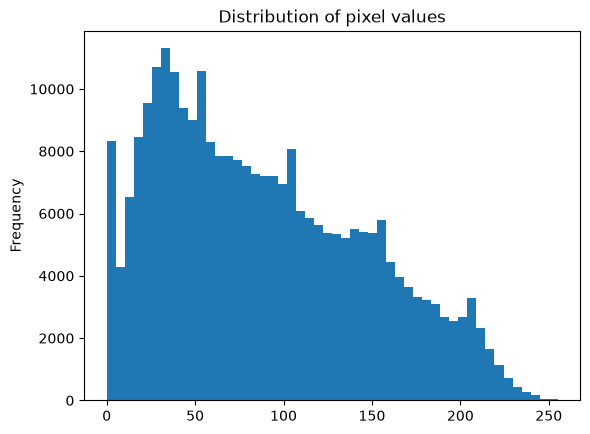

In [ ]:
# distribution of pixel values histogram 

pd.Series(img_mpl.flatten()).plot(kind='hist',
                                  bins =50,
                                  title = 'Distribution of pixel values')

plt.show()

### Operations on images

#### Display the images loaded by each method:

When **cv2** loads an image it loads it as `BGR`.   
so we have to pay attention when dealing with it later !    

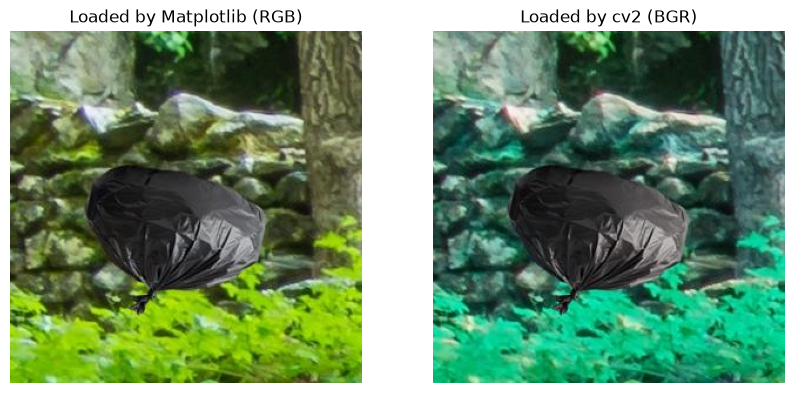

In [ ]:


fig, ax = plt.subplots(1,2 ,figsize =(10,5))

ax[0].imshow(img_mpl)
ax[0].set_title("Loaded by Matplotlib (RGB)")
ax[0].axis('off')

ax[1].imshow(img_cv2) 
ax[1].set_title("Loaded by cv2 (BGR)")
ax[1].axis('off')

plt.show()

- BGR to RGB

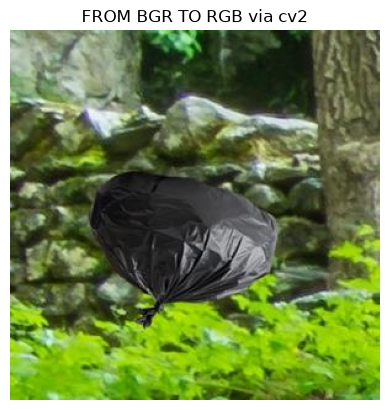

In [ ]:
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots()
ax.imshow(img_cv2_rgb)
ax.axis('off')
ax.set_title("FROM BGR TO RGB via cv2")
plt.show()

#### Display RGB Channels of one image

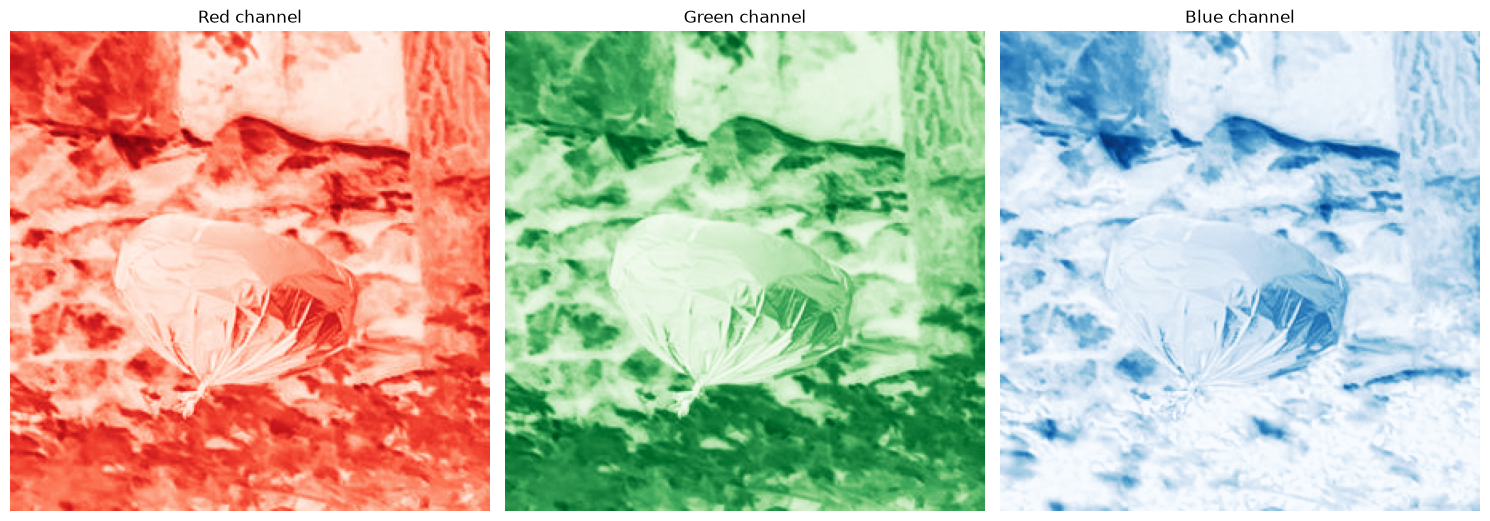

In [38]:
fig, axes = plt.subplots(1,3,figsize= (15,10))

axes[0].imshow(img_mpl[:,:,0], # show only the first channel
               cmap = 'Reds' # makes showing the color easier
               ) 
axes[0].axis('off')
axes[0].set_title("Red channel")


axes[1].imshow(img_mpl[:,:,1], cmap = 'Greens') 
axes[1].axis('off')
axes[1].set_title("Green channel")


axes[2].imshow(img_mpl[:,:,2], cmap = 'Blues') 
axes[2].axis('off')
axes[2].set_title("Blue channel")


plt.tight_layout()
plt.show()

#### Image color maipulation

In [74]:
img = plt.imread(paper_images[10]) # original

img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # RGB to gray


print("original image shape:")
print(img.shape)

print("\ngray image shape:")
print(img_gray.shape)

original image shape:
(300, 300, 3)

gray image shape:
(300, 300)


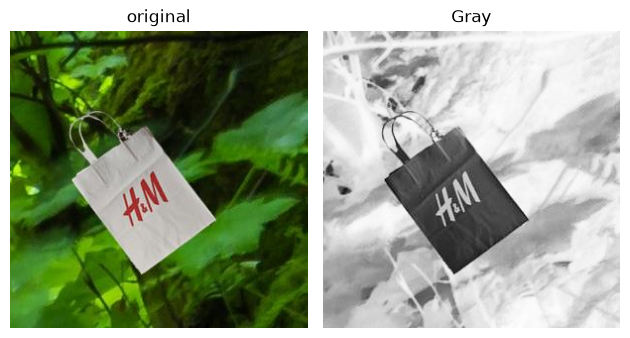

In [77]:
fig, ax = plt.subplots(1,2)

ax[0].imshow(img)
ax[0].axis('off')
ax[0].set_title("original")

ax[1].imshow(img_gray, cmap='Grays')
ax[1].axis('off')
ax[1].set_title("Gray")

plt.tight_layout()
plt.show()

#### Resizing and Scaling

Resized image shape:  (75, 75, 3)



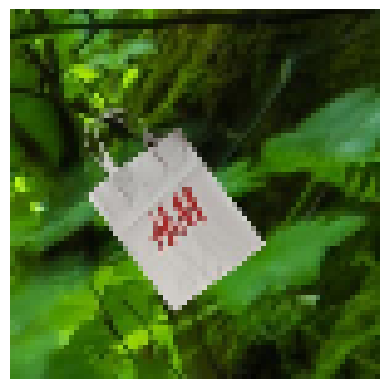

In [ ]:
# first method by using fx, fy  scaling factors
img_resized = cv2.resize(img,
                         None,
                         fx=0.25, 
                         fy=0.25    
                         )

fig, ax = plt.subplots()
ax.imshow(img_resized )
ax.axis('off')

print("Resized image shape: ",img_resized.shape)
print ("")

plt.show()

Resized image shape:  (160, 120, 3)



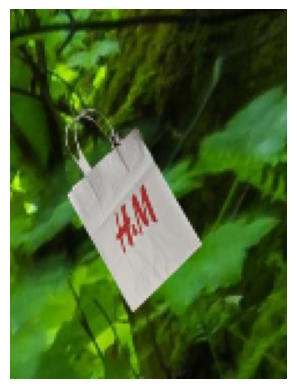

In [ ]:
# second way is by specifying  new dimensions
img_resized2 = cv2.resize(img, (120,160))

fig, ax = plt.subplots()
ax.imshow(img_resized2 )
ax.axis('off')

print("Resized image shape: ",img_resized2.shape)
print ("")
plt.show()

- **When upscaling `interpolation` must be USED !**

*interpolation*: it an algorithm that fills the middle pixls (new pixel) based on the values of the surrondings.  
            (it's like stretching then filling the stretched area to math its surronding.)

Resized image shape:  (3000, 3000, 3)



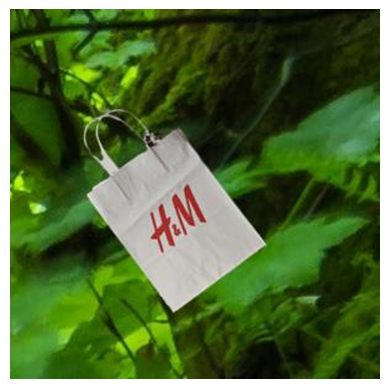

In [ ]:
img_resized_upscaled= cv2.resize(img,(3000,3000),interpolation= cv2.INTER_CUBIC)


fig, ax = plt.subplots()
ax.imshow(img_resized_upscaled )
ax.axis('off')

print("Resized image shape: ",img_resized_upscaled.shape)
print ("")
plt.show()

#### Normalizing

In [ ]:
# reduces pixel value from 0-255 to 0-1

img_normalized = img.astype(np.float32) / 255.0

print("normailized MIN: ",img_normalized.min())

print("normailized MAX: ",img_normalized.max())


normailized MIN:  0.0
normailized MAX:  0.99215686


#### cv2 kernals
<img src="https://edutir.analyticsvidhya.com/uploads/51269Capture.PNG" alt= "imgpixles" style = "width:400px;"/>


source = wikipedia

Based on different kernals we can get different effects when applied to the images.

such as: 
filtering, blurring, sharpening, etc..


- Sharpening

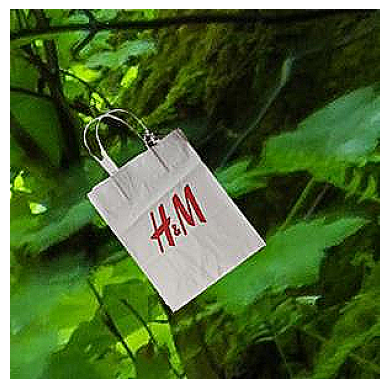

In [65]:
kernal_sharpening = np.array([[0,-1,0],
                              [-1,5,-1],
                              [0,-1,0]]
                             )

img_sharpened = cv2.filter2D(img,
                             -1, # depth
                             kernal_sharpening
                            )


fig, ax = plt.subplots()
ax.imshow(img_sharpened )
ax.axis('off')
plt.show()

- Blurring (box blur)

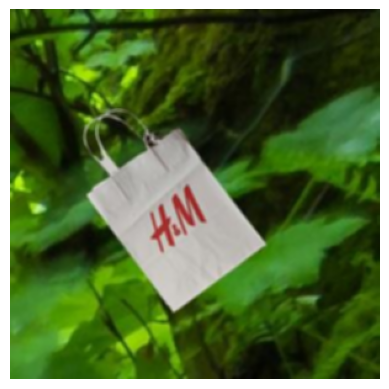

In [69]:
kernal_blurring = np.ones((3,3), np.float32) / 9

img_blurred = cv2.filter2D(img,
                             -1, # depth
                             kernal_blurring
                            )


fig, ax = plt.subplots()
ax.imshow(img_blurred )
ax.axis('off')
plt.show()

### HANDS-ON-LAB

#### OpenCV preprocessing function

This preprocessing works for CNN ! 

In [78]:
def preprocess_image(image_path, img_size = (130,130)):
    
    # read images with opencv
    img = cv2.imread(image_path)
    
    # convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # resize to fixed dimentions
    img = cv2.resize(img, img_size)
    
    # normalize pixel values from 0-255 to 0-1
    img = img.astype(np.float32) / 255.0
    
    return img

Shape: (130, 130, 3)
Data type: float32
Minimum: 0.0
Maximum: 0.9843137


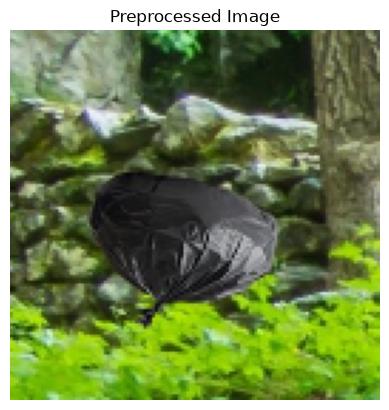

In [ ]:
# testing the function

sample_image = preprocess_image(bag_images[5])

print("Shape:", sample_image.shape)
print("Data type:", sample_image.dtype)

print("Minimum:", sample_image.min())
print("Maximum:", sample_image.max())

plt.imshow(sample_image)
plt.axis("off")
plt.title("Preprocessed Image")
plt.show()

#### Augmentaion pipeline

Goal is :       
creating slightly different version each training pass.  

**`Important NOTE`**:

augmentation layers expect something like:     
`(batch, height, width, channels)`

so dimention expantion (batch dimention) is needed before augmenting !

In [85]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomBrightness
)

In [ ]:
# Agumentation function(model)
augmentation = Sequential([
    RandomFlip("horizontal"), # mirrors some images
    RandomRotation(0.1),      # slightly rotate  
    RandomZoom(0.1),          # zooms in out
    RandomBrightness(0.1)     # change lighting
])

##### Visualizing augmented versions

In [ ]:
# dimention expantion (Adding the batch dimention)

sample_batch = tf.expand_dims(sample_image, axis=0) # sample_image already went throught the first function.

print (sample_batch.shape)

(1, 130, 130, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.994829..7.965718].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [9.064175..10.040791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [17.161722..18.128595].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.173316..9.143133].


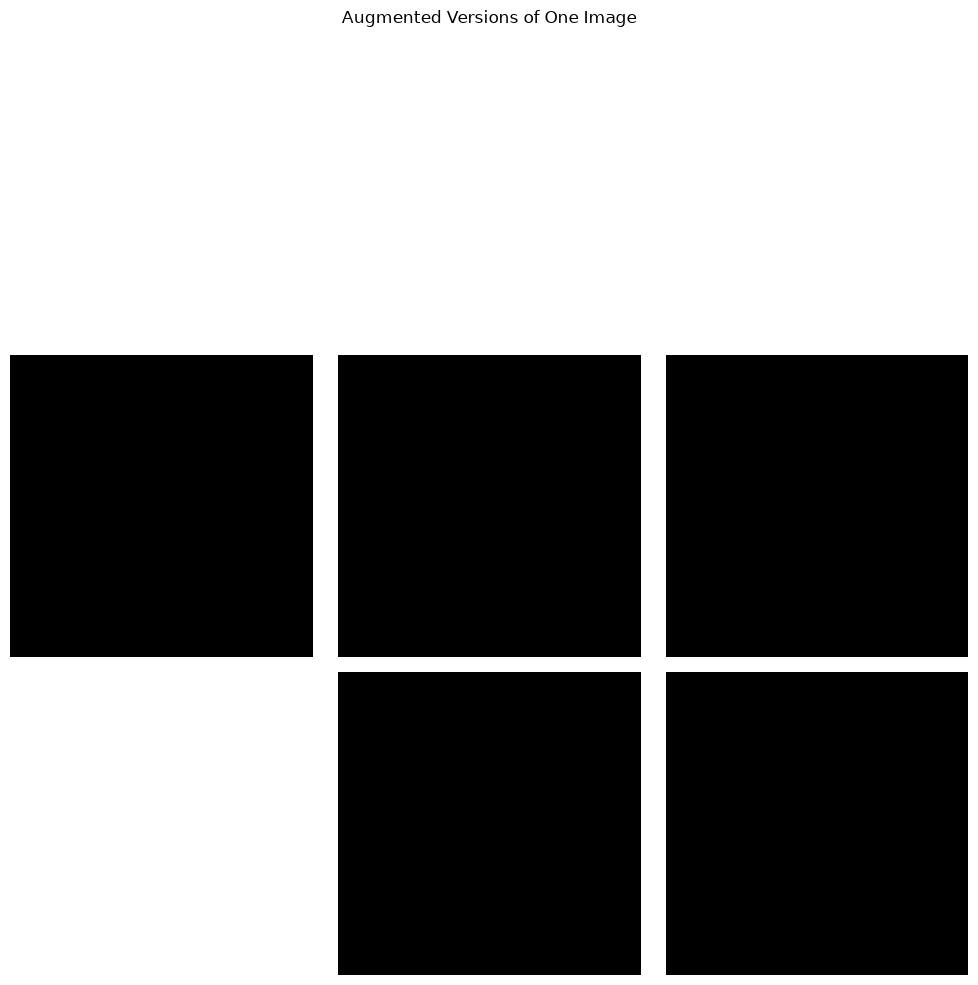

In [94]:
plt.figure(figsize=(10,10))

for i in range(9):
    
    augmented_image = augmentation(sample_batch,training = True)
    
    plt.subplot(3,3, i+1)
    
    plt.imshow(augmented_image[0].numpy())
    
    plt.axis("off")
    
plt.suptitle("Augmented Versions of One Image")
plt.tight_layout()
plt.show()

#### Transfer Learning preprocessing function

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input 


##### Preprocessing function for MobileNetV2:

- MobileNetV2 expects its own preprocessing.

In [97]:
def preprocess_for_mobilenet(image_path, img_size=(130, 130)):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, img_size)

    img = img.astype(np.float32)

    img = preprocess_input(img) # special preprocessing for mobileNet
                                # it handles the scaling expected by mobileNet so we dont do (img / 255.0)
                                # 0 → 255 To -1 → 1 
    return img

In [ ]:
# testing the function 

mobilenet_img = preprocess_for_mobilenet(bag_images[5])

print("Shape:", mobilenet_img.shape)
print("Minimum:", mobilenet_img.min())
print("Maximum:", mobilenet_img.max())

Shape: (130, 130, 3)
Minimum: -1.0
Maximum: 0.96862745


#### **OpenCV Preprocessing & Augmentation Conclustion**

An OpenCV preprocessing function was created to load images, convert them from BGR to RGB, resize them to a consistent size, and normalize their pixel values.

An augmentation pipeline was also created using random flipping, rotation, zoom, and brightness changes. Multiple augmented versions of one image were visualized to verify that transformations were applied correctly.

For the pretrained MobileNetV2 model, the standard preprocess_input function was used instead of normal 0–1 scaling. This ensures that prediction-time preprocessing matches the preprocessing expected by the pretrained model.